Student 2: Logistic Regression
Notebook must include:
1. Dataset loading and cleaning.
2. EDA relevant to logistic regression assumptions.
3. Logistic regression model code.
4. Model performance evidence.
5. Coefficient or odds-ratio interpretation in markdown.
6. At least one limitation of using logistic regression for churn.


## Dataset loading

In [1]:

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## EDA

In [3]:
#EDA

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## DATA PROCESSING

In [6]:

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df['InternetService'].value_counts()


InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [8]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [9]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [10]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [11]:

df_encode = df.copy()
df_encode = df_encode.drop(columns=['customerID'])

binary_cols = [
    'Churn',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling'
]

for col in binary_cols:
    df_encode[col] = df_encode[col].map({
        'No': 0,
        'Yes': 1
    })

df_encode['gender'] = df_encode['gender'].map({
    'Female': 0,
    'Male': 1
})


categorical_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

df_encode = pd.get_dummies(
    df_encode,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [12]:
df_encode['TotalCharges'] = pd.to_numeric(
    df_encode['TotalCharges'],
    errors='coerce'
)

In [13]:
df_encode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [14]:
#print(df_encode.isna().sum())

In [15]:
df_encode = df_encode.dropna(subset=['TotalCharges'])

## Logestic Regression 

In [16]:
# Check Multicollinearity
corr = df_encode[
    ['tenure', 'MonthlyCharges', 'TotalCharges']
].corr()

print(corr)

                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.246862      0.825880
MonthlyCharges  0.246862        1.000000      0.651065
TotalCharges    0.825880        0.651065      1.000000


TotalCharges is highly correlated with other numerical variables

In [17]:
X = df_encode.drop(columns=['Churn'])
y = df_encode['Churn']

# Split train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale all features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [19]:
# Predictions
lr_pred = model.predict(X_test)
lr_prob = model.predict_proba(X_test)[:, 1]

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_auc_score)

import matplotlib.pyplot as plt

print(f"Accuracy:  {accuracy_score(y_test, lr_pred):.3f}")
print(f"Precision: {precision_score(y_test, lr_pred):.3f}")
print(f"Recall:    {recall_score(y_test, lr_pred):.3f}")
print(f"F1 Score:  {f1_score(y_test, lr_pred):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_prob):.3f}")

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Accuracy:  0.788
Precision: 0.623
Recall:    0.516
F1 Score:  0.564
ROC-AUC:   0.832

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



## Model performance 

In [21]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0],
    "Odds_Ratio": np.exp(model.coef_[0])
})

coef_df = coef_df.sort_values("Odds_Ratio",ascending=False
)

coef_df.round(3)

,Feature,Coefficient,Odds_Ratio
11,InternetService_Fiber optic,0.665,1.944
6,PaperlessBilling,0.276,1.318
28,PaymentMethod_Electronic check,0.266,1.304
9,MultipleLines_No phone service,0.264,1.302
1,SeniorCitizen,0.258,1.294
10,MultipleLines_Yes,0.197,1.217
24,StreamingMovies_Yes,0.196,1.217
22,StreamingTV_Yes,0.179,1.196
2,Partner,0.052,1.053
7,MonthlyCharges,0.004,1.004


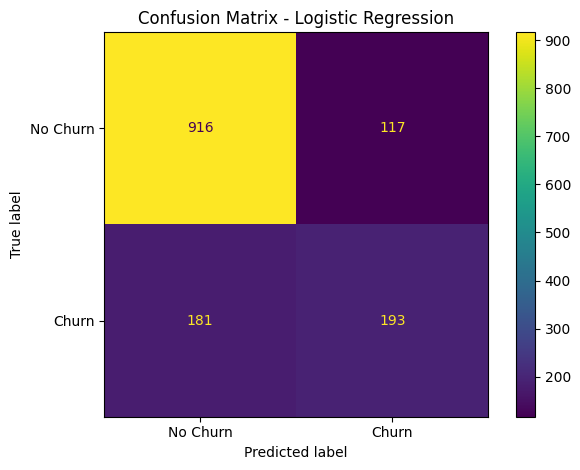

In [22]:
# Confusion Matrix:
from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay)

cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['No Churn', 'Churn'])

disp.plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()


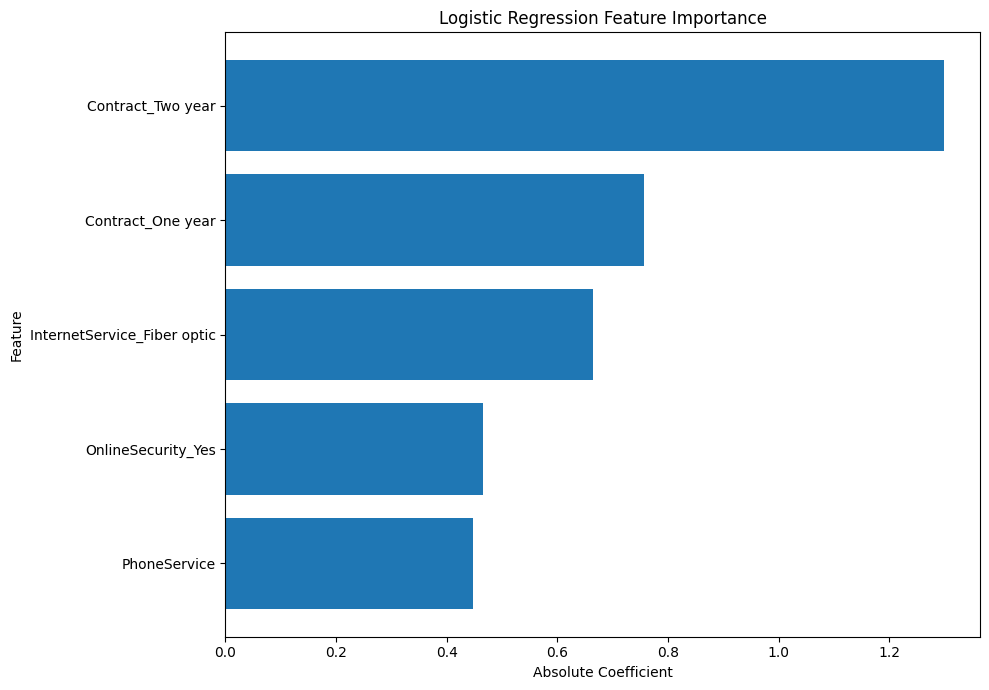

In [23]:
# Feature importance based on absolute logistic regression coefficients
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

importance_df['Importance'] = abs(importance_df['Coefficient'])

# Sort and select top 15
importance_df = importance_df.sort_values('Importance', ascending=False).head(5)

# Plot
plt.figure(figsize=(10, 7))

plt.barh(importance_df['Feature'], importance_df['Importance']
)

plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.title('Logistic Regression Feature Importance')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Coefficient and Odds-Ratio Interpretation

- **Two-year contract:** This is the strongest predictor in the model, with a coefficient of -1.288 and an odds ratio of 0.276. Holding other variables constant, customers with two-year contracts have approximately 72.4% lower odds of churn than customers with month-to-month contracts.

- **One-year contract:** The coefficient is -0.748 with an odds ratio of 0.473. Customers with one-year contracts have approximately 52.7% lower odds of churn than customers with month-to-month contracts.

- **Fiber-optic internet:** Fiber-optic service has the strongest positive coefficient (0.663) and an odds ratio of 1.94. Customers with fiber-optic internet have approximately 94% higher odds of churn than customers in the reference internet-service category, holding other predictors constant.

- **Online security:** Customers with online security have a coefficient of -0.469 and an odds ratio of 0.625, corresponding to approximately 37.5% lower odds of churn relative to the reference category.

- **Phone service:** Phone service has a coefficient of -0.455 and an odds ratio of 0.634, corresponding to approximately 36.6% lower odds of churn, holding the other variables constant.

Overall, longer-term contracts appear to be particularly strongly associated with customer retention, while fiber-optic service is associated with higher churn odds. These relationships are associations estimated by the logistic regression model and should not be interpreted as causal effects.

In [24]:
df_encode["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

### Limitation 

1. Logestic regression assumes that continuous predictors have an approximately linear relationship with the log-odds of churn. Customer behavior
may contain nonlinear patterns or interactions that are not captured by the model unless they are explicitly included.

2. Churn is imbalanced with fewer customers belonging to the churn class. As a result, the default 0.5 classification threshold may favor the majority non-churn class and fail to identify some customers who actually churn. For this reason, recall, F1-score, and ROC-AUC are considered alongside accuracy.